In [1]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

In [2]:
data_path = "/home/riccardo/Documents/orbit/source/standalone/logs/rsl_rl/unitree_go1_jump/"

In [3]:
# results = data_path +"_test.bin"
results = data_path +"test.bin"
fail = data_path +"failed.bin"

In [4]:
data = joblib.load(results)
fail_data = joblib.load(fail)

In [5]:
data.shape

(2, 8000, 3)

In [6]:
failed_idx = np.nonzero(fail_data)[0]

In [7]:
des = data[0][:,:2]
des.shape

(8000, 2)

In [8]:
xmin, xmax = des[:,0].min(), des[:,0].max()

In [9]:
ymin, ymax = des[:,1].min(), des[:,1].max()

In [10]:
# des = data[0][:, :2][(abs(data[0][:, 1]) < 0.3) & (data[0][:, 0] >= 0)]
# des.shape

In [11]:
actual = data[1][:,:2]
actual.shape

(8000, 2)

In [12]:
# actual = data[1][:, :2][(abs(data[0][:, 1]) < 0.3) & (data[0][:, 0] >= 0)]
# actual.shape

In [13]:
err = np.linalg.norm(des - actual, axis=1)
err

array([0.12402795, 0.05132011, 0.11667848, ..., 0.0745331 , 0.06018178,
       0.33970052], dtype=float32)

In [14]:
failed_jump = des[failed_idx]

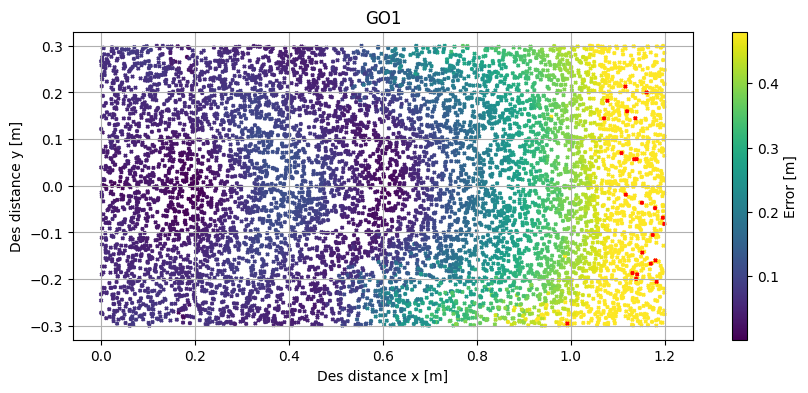

In [15]:
plt.figure(figsize=(10, 4))
plt.scatter(failed_jump[:, 0], failed_jump[:, 1], np.full(failed_jump[: , 1].shape, 5), marker='x', color="red", zorder=1)
plt.scatter(des[:, 0], des[:, 1], np.full(des[: , 1].shape, 5), vmax=0.48, marker='x', c=err, zorder=0)
# plt.xlim(xmin * 1.05, xmax * 1.05)
# plt.ylim(ymin * 1.1, ymax * 1.1)
plt.grid()
plt.title("GO1")
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path + "abs_err.pdf", dpi=500, bbox_inches='tight')
plt.show()

In [16]:
idx = err <= 0.2

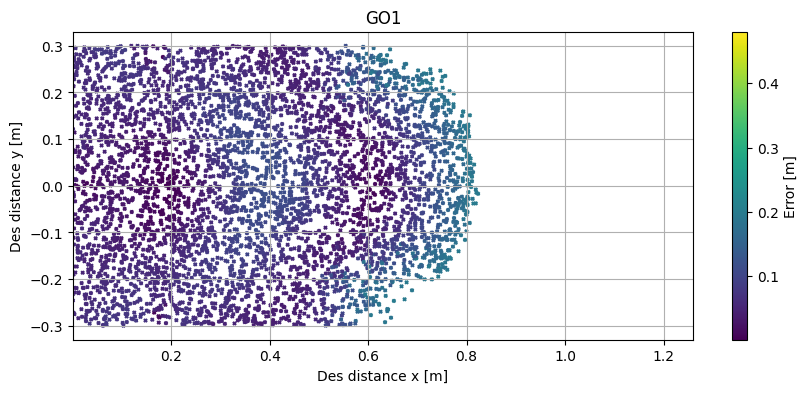

In [17]:
plt.figure(figsize=(10,4))
plt.scatter(des[:,0][idx],des[:,1][idx], np.full(des[: , 1].shape,5)[idx], vmax=0.48, marker='x', c=err[idx])
plt.grid()
plt.xlim(xmin*1.05,xmax*1.05)
plt.ylim(ymin*1.1,ymax*1.1)
plt.title("GO1")
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"abs_err_filtered.pdf", dpi=500, bbox_inches='tight')
plt.show()

In [18]:
des_dist = np.linalg.norm(des, axis=1)
des_dist

array([0.7311987 , 0.18040979, 0.6581706 , ..., 0.4227033 , 0.25223383,
       0.9473228 ], dtype=float32)

In [19]:
actual_dist = np.linalg.norm(actual, axis=1)
actual_dist

array([0.61185753, 0.21431154, 0.5501388 , ..., 0.48634982, 0.3003331 ,
       0.61019415], dtype=float32)

In [20]:
np.linalg.norm([0.6,.3])

0.6708203932499369

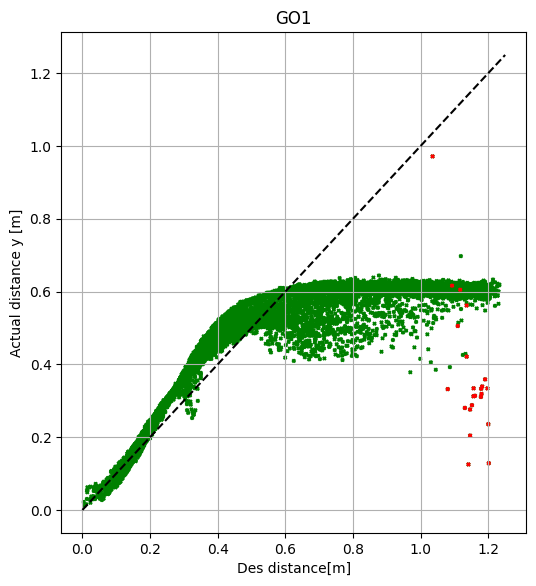

In [21]:

plt.figure(figsize=(6, 6.5))
plt.grid()
plt.scatter(des_dist,actual_dist, np.full(des_dist.shape,5), marker='x', alpha=1, color="green")
plt.scatter(des_dist[failed_idx],actual_dist[failed_idx], np.full(des_dist[failed_idx].shape,5), marker='x', alpha=1, color="red")
plt.title("GO1")
plt.plot([0.0,1.25],[0.0,1.25], '--', color="black")
# plt.colorbar(label="Error [m]")
plt.xlabel("Des distance[m]")
plt.ylabel("Actual distance y [m]")
plt.savefig(data_path+"diag_err.pdf", dpi=500, bbox_inches='tight')
plt.show()

In [25]:
perc_err = err / des_dist
perc_err

array([0.01298303, 0.21613726, 0.14538118, ..., 0.21215297, 0.34654844,
       0.18368337], dtype=float32)

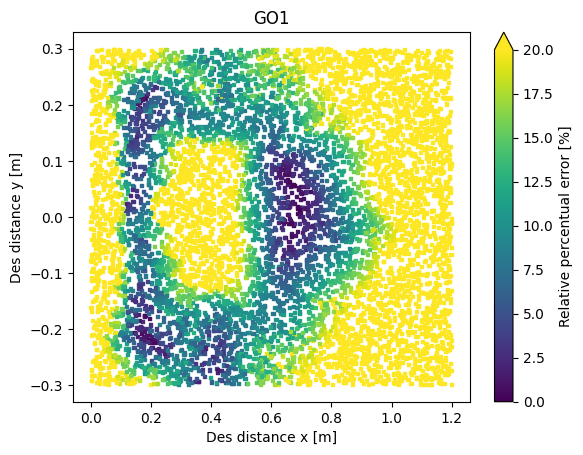

In [26]:
plt.scatter(des[:,0],des[:,1], np.full(des[: , 1].shape,5), marker='s', c=perc_err*100, vmin=0, vmax=20)
plt.colorbar(label="Relative percentual error [%]", extend='max')
plt.title("GO1")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"perc_err.pdf", dpi=500, bbox_inches='tight')
plt.show()

In [25]:
# results = data_path +"_test.bin"
results = data_path +"test.bin"
fail = data_path +"failed.bin"

In [26]:
data = joblib.load(results)
fail_data = joblib.load(fail)

In [27]:
data

array([[[ 0.34036255, -0.08283997,  0.5       ],
        [ 0.4056244 ,  0.04649353,  0.5       ],
        [ 0.72888184, -0.11552429,  0.5       ],
        ...,
        [ 0.36965942, -0.2355957 ,  0.5       ],
        [ 0.9637451 ,  0.02241516,  0.5       ],
        [ 0.00283813,  0.02163696,  0.5       ]],

       [[ 0.34472656, -0.08283997,  0.5000001 ],
        [ 0.4084015 ,  0.04602051,  0.5000002 ],
        [ 0.72224426, -0.11529541,  0.4999983 ],
        ...,
        [ 0.37374878, -0.23921204,  0.5000013 ],
        [ 0.86273193,  0.02261353,  0.4999971 ],
        [-0.0243988 ,  0.04977417,  0.50000226]]], dtype=float32)

In [28]:
data.shape

(2, 10000, 3)

In [29]:
failed_idx = np.nonzero(fail_data)[0]

In [30]:
des = data[0][:,:2]
des.shape

(10000, 2)

In [31]:
xmin, xmax = des[:,0].min(), des[:,0].max()

In [32]:
ymin, ymax = des[:,1].min(), des[:,1].max()

In [33]:
actual = data[1][:,:2]
actual.shape

(10000, 2)

In [34]:
err = np.linalg.norm(des - actual, axis=1)
err

array([0.00436401, 0.0028171 , 0.00664152, ..., 0.005459  , 0.10101338,
       0.03916061], dtype=float32)

In [35]:
failed_jump = des[failed_idx]

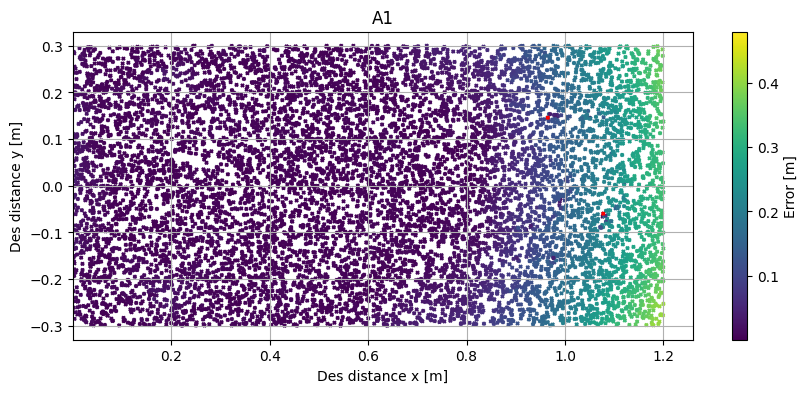

In [36]:
plt.figure(figsize=(10, 4))
plt.scatter(failed_jump[:, 0], failed_jump[:, 1], np.full(failed_jump[: , 1].shape, 5), marker='x', color="red", zorder=1)
plt.scatter(des[:, 0], des[:, 1], np.full(des[: , 1].shape, 5), vmax=0.48, marker='x', c=err, zorder=0)
plt.xlim(xmin * 1.05, xmax * 1.05)
plt.ylim(ymin * 1.1, ymax * 1.1)
plt.grid()
plt.title("A1")
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path + "abs_err.pdf", dpi=500, bbox_inches='tight')
plt.show()

In [37]:
idx = err <= 0.2

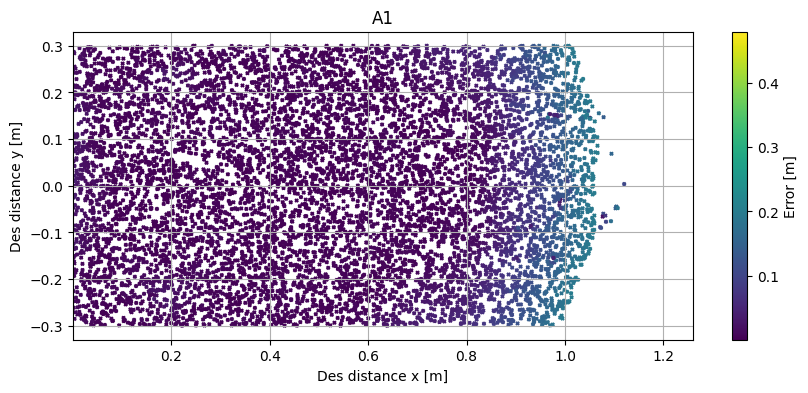

In [38]:
plt.figure(figsize=(10,4))
plt.scatter(des[:,0][idx],des[:,1][idx], np.full(des[: , 1].shape,5)[idx], vmax=0.48, marker='x', c=err[idx])
plt.grid()
plt.xlim(xmin*1.05,xmax*1.05)
plt.ylim(ymin*1.1,ymax*1.1)
plt.title("A1")
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"abs_err_filtered.pdf", dpi=500, bbox_inches='tight')
plt.show()

In [39]:
des_dist = np.linalg.norm(des, axis=1)
des_dist

array([0.3502986 , 0.40828028, 0.73798007, ..., 0.4383531 , 0.96400577,
       0.02182231], dtype=float32)

In [40]:
actual_dist = np.linalg.norm(actual, axis=1)
actual_dist

array([0.35454035, 0.4109862 , 0.731389  , ..., 0.44374603, 0.8630282 ,
       0.05543257], dtype=float32)

In [41]:
np.linalg.norm([0.6,.3])

0.6708203932499369

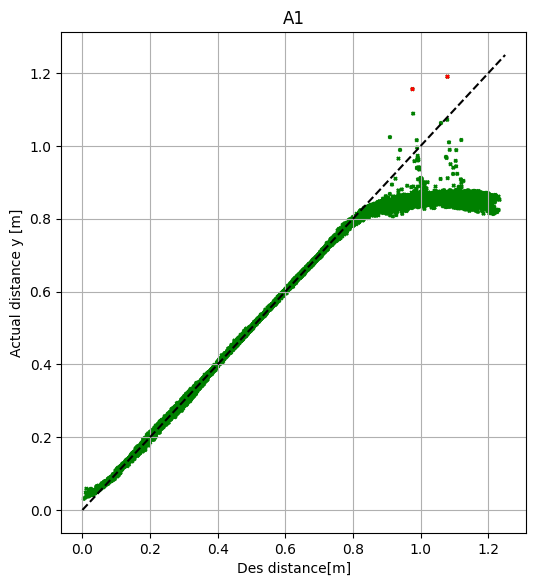

In [42]:

plt.figure(figsize=(6, 6.5))
plt.grid()
plt.scatter(des_dist,actual_dist, np.full(des_dist.shape,5), marker='x', alpha=1, color="green")
plt.scatter(des_dist[failed_idx],actual_dist[failed_idx], np.full(des_dist[failed_idx].shape,5), marker='x', alpha=1, color="red")
plt.title("A1")
plt.plot([0.0,1.25],[0.0,1.25], '--', color="black")
# plt.colorbar(label="Error [m]")
plt.xlabel("Des distance[m]")
plt.ylabel("Actual distance y [m]")
plt.savefig(data_path+"diag_err.pdf", dpi=500, bbox_inches='tight')
plt.show()

In [43]:
perc_err = err / des_dist
perc_err

array([0.01245798, 0.00689991, 0.00899959, ..., 0.01245343, 0.10478503,
       1.7945218 ], dtype=float32)

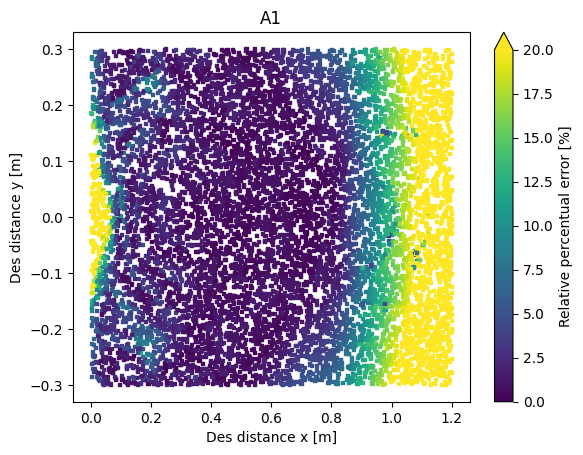

In [44]:
plt.scatter(des[:,0],des[:,1], np.full(des[: , 1].shape,5), marker='s', c=perc_err*100, vmin=0, vmax=20)
plt.colorbar(label="Relative percentual error [%]", extend='max')
plt.title("A1")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"perc_err.pdf", dpi=500, bbox_inches='tight')
plt.show()